In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print("Working from:", Path.cwd())

Working from: /home/bluebash-77/Documents/python/DS/projects


In [15]:
import pandas as pd
from sqlalchemy import text

from app.db.session import engine

REPOS = [
    "fastapi/fastapi",
    "pallets/flask",
    "psf/requests",
    "encode/httpx",
    "pydantic/pydantic",
]

PR_QUERY = text("""
SELECT
    r.full_name                     AS repo,
    p.number,
    p.title,
    p.author_login,
    p.status,
    p.created_at,
    p.closed_at,
    p.merged_at,
    COUNT(f.id)                     AS files_changed,
    COALESCE(SUM(f.additions), 0)   AS additions,
    COALESCE(SUM(f.deletions), 0)   AS deletions,
    COUNT(f.id) FILTER (WHERE f.path ILIKE '%test%')                                               AS test_files,
    COUNT(f.id) FILTER (WHERE f.path ILIKE '%.md' OR f.path ILIKE '%.rst' OR f.path ILIKE 'docs/%') AS doc_files
FROM pull_requests p
JOIN repositories r            ON r.id = p.repository_id
LEFT JOIN pull_request_files f ON f.pull_request_id = p.id
WHERE r.full_name = ANY(:repos)
GROUP BY r.full_name, p.id
""")

with engine.connect() as conn:
    prs = pd.read_sql(PR_QUERY, conn, params={"repos": REPOS})

print(prs.shape)

(300, 13)


In [17]:
prs["merged_at"] = pd.to_datetime(prs["merged_at"], utc=True)

prs["is_merged"] = prs["merged_at"].notna()
prs["is_bot"] = prs["author_login"].str.endswith("[bot]", na=False)
prs["lines_changed"] = prs["additions"] + prs["deletions"]
prs["hours_to_close"] = (prs["closed_at"] - prs["created_at"]).dt.total_seconds() / 3600

prs.head()

,repo,number,title,author_login,status,created_at,closed_at,merged_at,files_changed,additions,deletions,test_files,doc_files,is_merged,is_bot,lines_changed,hours_to_close
0,encode/httpx,3620,chore: update sponsorship graphic,chailandau,closed,2025-08-04 20:16:31+00:00,2025-08-07 13:52:25+00:00,2025-08-07 13:52:25+00:00,1,0,0,0,1,True,False,0,65.598333
1,psf/requests,7560,utils: surface clear ValueError from address_i...,HrachShah,closed,2026-07-05 09:47:52+00:00,2026-07-05 09:48:05+00:00,NaT,2,92,5,1,0,False,False,97,0.003611
2,pallets/flask,6099,AI junk,eeshsaxena,closed,2026-07-20 01:51:12+00:00,2026-07-20 02:08:46+00:00,NaT,2,20,27,2,0,False,False,47,0.292778
3,fastapi/fastapi,16386,🐛 Fix stale Content-Length header for 205 Rese...,prownd,closed,2026-09-22 07:12:00+00:00,2026-09-22 08:40:34+00:00,NaT,2,36,0,1,0,False,False,36,1.476111
4,pydantic/pydantic,13824,Add a `counter` core schema,Viicos,closed,2026-09-17 11:47:29+00:00,2026-09-17 11:57:54+00:00,2026-09-17 11:57:54+00:00,31,1111,19,7,3,True,False,1130,0.173611


In [7]:
prs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   repo            300 non-null    object             
 1   number          300 non-null    int64              
 2   title           300 non-null    object             
 3   author_login    300 non-null    object             
 4   status          300 non-null    object             
 5   created_at      300 non-null    datetime64[ns, UTC]
 6   closed_at       300 non-null    datetime64[ns, UTC]
 7   merged_at       78 non-null     datetime64[ns, UTC]
 8   files_changed   300 non-null    int64              
 9   additions       300 non-null    int64              
 10  deletions       300 non-null    int64              
 11  test_files      300 non-null    int64              
 12  doc_files       300 non-null    int64              
 13  is_merged       300 non-null    boo

In [10]:
summary = prs.groupby("repo").agg(
    prs=("number", "count"),
    merge_rate=("is_merged", "mean"),
    bot_share=("is_bot", "mean"),
    median_files=("files_changed", "median"),
    median_lines=("lines_changed", "median"),
    median_hours_to_close=("hours_to_close", "median"),
    zero_file_prs=("files_changed", lambda s: (s == 0).sum()),
)
summary.round(2)

,prs,merge_rate,bot_share,median_files,median_lines,median_hours_to_close,zero_file_prs
repo,,,,,,,
encode/httpx,60,0.32,0.12,2.0,19.5,25.69,1
fastapi/fastapi,60,0.15,0.15,2.0,43.0,5.68,2
pallets/flask,60,0.05,0.00,2.0,16.0,0.36,0
psf/requests,60,0.30,0.25,2.0,15.5,0.98,1
pydantic/pydantic,60,0.48,0.03,2.0,45.5,0.25,0


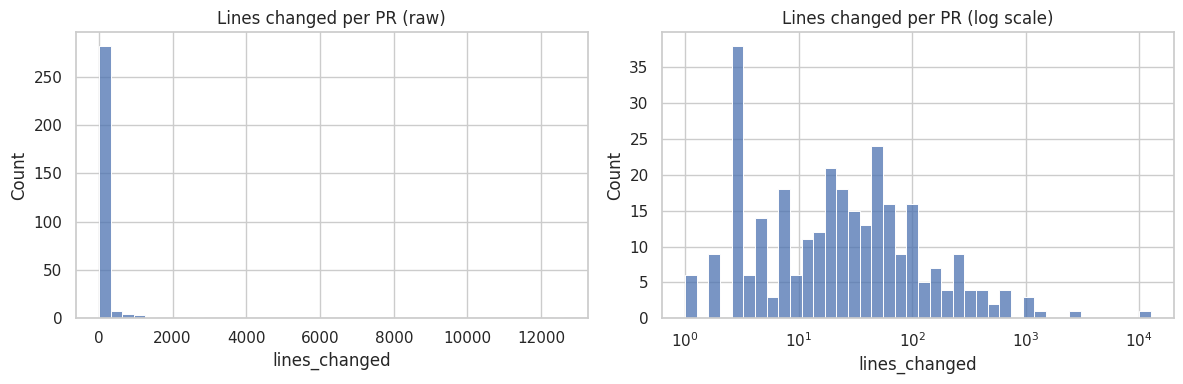

count      300.0
mean       127.6
std        759.4
min          0.0
50%         22.5
75%         63.5
90%        201.7
99%       1147.7
max      12631.0
Name: lines_changed, dtype: float64
mean / median: 5.7


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(prs["lines_changed"], bins=40, ax=axes[0])
axes[0].set_title("Lines changed per PR (raw)")

sns.histplot(prs["lines_changed"] + 1, bins=40, log_scale=True, ax=axes[1])
axes[1].set_title("Lines changed per PR (log scale)")

plt.tight_layout()
plt.show()

print(prs["lines_changed"].describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(1))
print("mean / median:", round(prs["lines_changed"].mean() / prs["lines_changed"].median(), 1))

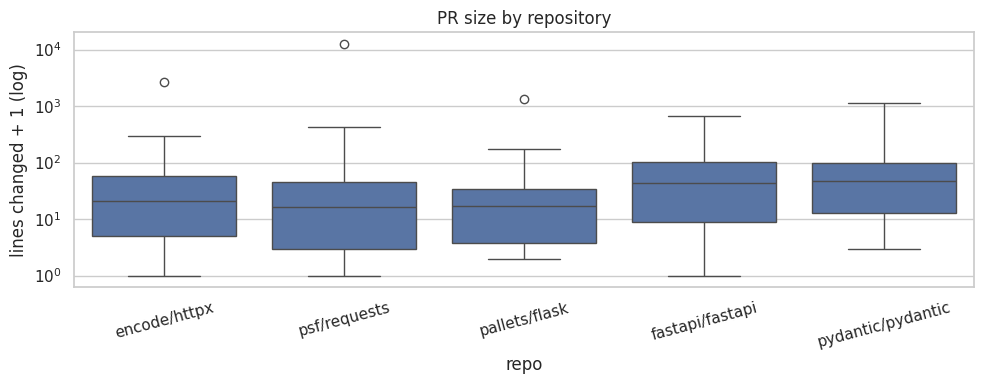

In [19]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=prs, x="repo", y=prs["lines_changed"] + 1, log_scale=True)
plt.ylabel("lines changed + 1 (log)")
plt.title("PR size by repository")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

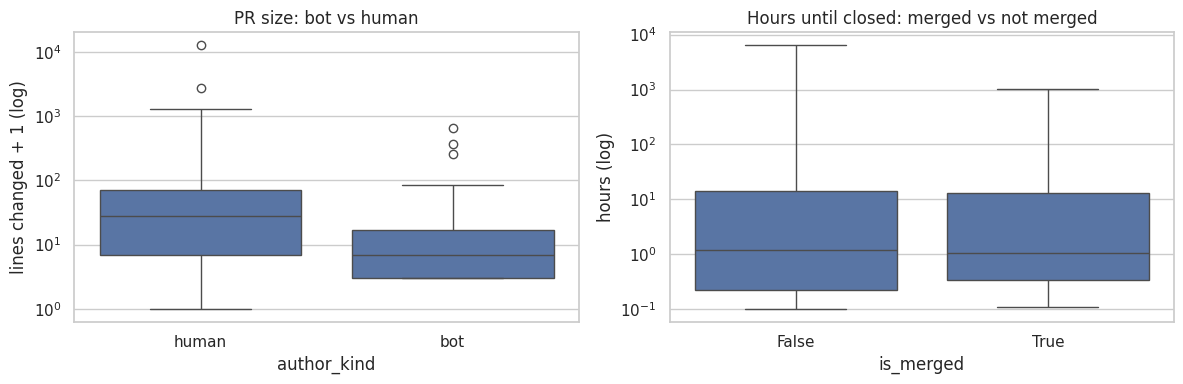

author_kind
bot       6.0
human    27.0
Name: lines_changed, dtype: float64
is_merged
False    1.1
True     0.9
Name: hours_to_close, dtype: float64


In [20]:
import numpy as np

prs["author_kind"] = np.where(prs["is_bot"], "bot", "human")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=prs, x="author_kind", y=prs["lines_changed"] + 1, log_scale=True, ax=axes[0])
axes[0].set_title("PR size: bot vs human")
axes[0].set_ylabel("lines changed + 1 (log)")

sns.boxplot(data=prs, x="is_merged", y=prs["hours_to_close"] + 0.1, log_scale=True, ax=axes[1])
axes[1].set_title("Hours until closed: merged vs not merged")
axes[1].set_ylabel("hours (log)")

plt.tight_layout()
plt.show()

print(prs.groupby("author_kind")["lines_changed"].median())
print(prs.groupby("is_merged")["hours_to_close"].median().round(1))